In [2]:
!pip install statsbombpy
!pip install mplsoccer
!pip install pandas
!pip install matplotlib
!pip install numpy

In [3]:
from statsbombpy import sb
from mplsoccer import Pitch
import pandas as pd
import matplotlib.pyplot as plt

print("All good. Let's go.")

All good. Let's go.


In [4]:
isl_matches = sb.matches(competition_id=1238, season_id=108)
print(isl_matches[['match_id', 'home_team', 'away_team', 'home_score', 'away_score']].to_string())

     match_id                home_team                away_team  home_score  away_score
0     3827336  Mohun Bagan Super Giant                 SC Delhi           1           0
1     3813314  Mohun Bagan Super Giant          Kerala Blasters           4           2
2     3817877         NorthEast United                Bengaluru           2           1
3     3827767                 SC Delhi          Kerala Blasters           1           1
4     3827335          Kerala Blasters               Jamshedpur           1           1
5     3827338                 SC Delhi  Mohun Bagan Super Giant           3           1
6     3827337               Jamshedpur          Kerala Blasters           0           1
7     3817856  Mohun Bagan Super Giant               Jamshedpur           0           1
8     3817891              East Bengal                Bengaluru           0           1
9     3817870                      Goa          Kerala Blasters           4           4
10    3817899               Jams

In [5]:
events = sb.events(match_id=3813312)
print(events.shape)
print(events['type'].value_counts())

(2974, 94)
type
Pass                 848
Ball Receipt*        775
Carry                707
Pressure             195
Ball Recovery         89
Duel                  46
Dribble               33
Goal Keeper           32
Clearance             28
Shot                  28
Miscontrol            26
Dribbled Past         23
Foul Committed        22
Interception          22
Block                 20
Foul Won              20
Injury Stoppage       13
Dispossessed          12
Substitution          10
Referee Ball-Drop      7
Half Start             4
Half End               4
Starting XI            2
Offside                2
Shield                 2
Tactical Shift         2
Player Off             1
Player On              1
Name: count, dtype: int64


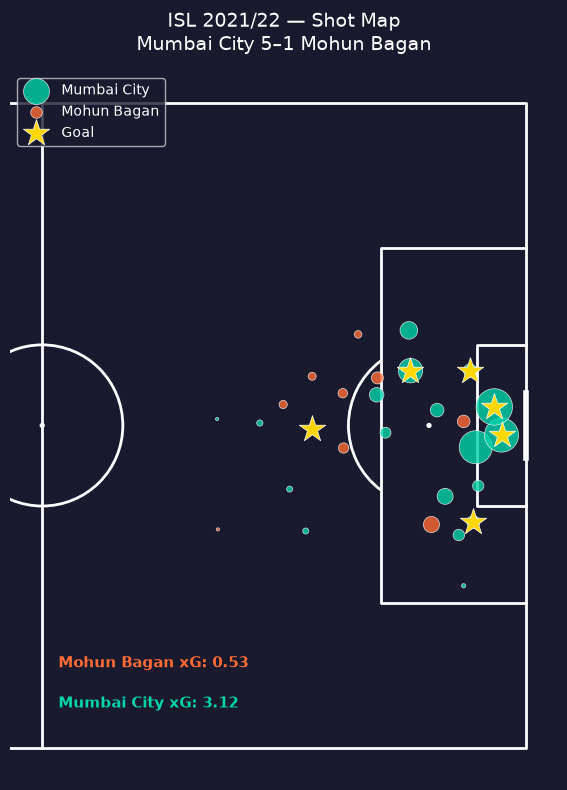

Saved!


In [6]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# Filter shots
shots = events[events['type'] == 'Shot'].copy()
shots['x'] = shots['location'].apply(lambda loc: loc[0])
shots['y'] = shots['location'].apply(lambda loc: loc[1])
shots['xg'] = shots['shot_statsbomb_xg']

# Separate teams
mumbai = shots[shots['team'] == 'Mumbai City']
mohun = shots[shots['team'] == 'Mohun Bagan Super Giant']

# Draw half pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='#1a1a2e', line_color='white', half=True)
fig, ax = pitch.draw(figsize=(12, 8))
fig.patch.set_facecolor('#1a1a2e')

# Mumbai shots (teal)
pitch.scatter(mumbai['x'], mumbai['y'],
              s=mumbai['xg'] * 1000,
              c='#00d4aa', edgecolors='white', linewidth=0.5,
              alpha=0.8, ax=ax, zorder=3, label='Mumbai City')

# Mohun Bagan shots (green)
pitch.scatter(mohun['x'], mohun['y'],
              s=mohun['xg'] * 1000,
              c='#ff6b35', edgecolors='white', linewidth=0.5,
              alpha=0.8, ax=ax, zorder=3, label='Mohun Bagan')

# Goals
goals = shots[shots['shot_outcome'] == 'Goal']
pitch.scatter(goals['x'], goals['y'],
              s=400, c='gold', marker='*',
              edgecolors='white', linewidth=0.5,
              ax=ax, zorder=4, label='Goal')

# Title and legend
ax.set_title('ISL 2021/22 — Shot Map\nMumbai City 5–1 Mohun Bagan',
             color='white', fontsize=14, pad=15)
ax.legend(loc='upper left', facecolor='#1a1a2e', labelcolor='white', fontsize=10)

# xG totals
mumbai_xg = mumbai['xg'].sum()
mohun_xg = mohun['xg'].sum()
ax.text(62, 75, f'Mumbai City xG: {mumbai_xg:.2f}', color='#00d4aa', fontsize=11, fontweight='bold')
ax.text(62, 70, f'Mohun Bagan xG: {mohun_xg:.2f}', color='#ff6b35', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('isl_mumbai_mohunbagan_shotmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

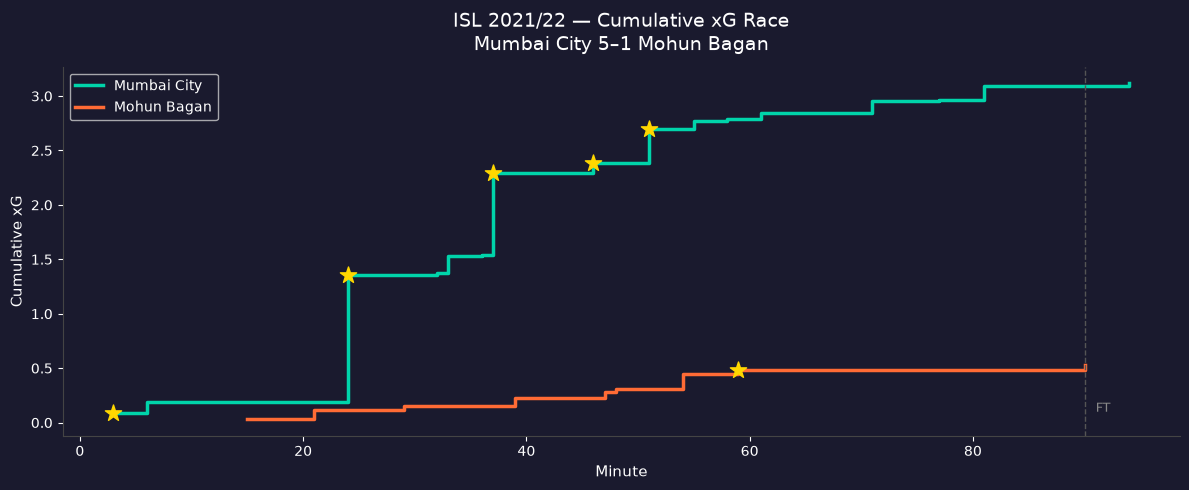

Saved!


In [7]:
# xG race
shots = events[events['type'] == 'Shot'].copy()
shots['minute_'] = shots['minute']
shots['xg'] = shots['shot_statsbomb_xg']

mumbai_shots = shots[shots['team'] == 'Mumbai City'].sort_values('minute_')
mohun_shots = shots[shots['team'] == 'Mohun Bagan Super Giant'].sort_values('minute_')

mumbai_shots['cumxg'] = mumbai_shots['xg'].cumsum()
mohun_shots['cumxg'] = mohun_shots['xg'].cumsum()

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

ax.step(mumbai_shots['minute_'], mumbai_shots['cumxg'],
        where='post', color='#00d4aa', linewidth=2.5, label='Mumbai City')
ax.step(mohun_shots['minute_'], mohun_shots['cumxg'],
        where='post', color='#ff6b35', linewidth=2.5, label='Mohun Bagan')

# Mark goals
goals = shots[shots['shot_outcome'] == 'Goal']
for _, g in goals.iterrows():
    team_shots = mumbai_shots if g['team'] == 'Mumbai City' else mohun_shots
    cum = team_shots[team_shots['minute_'] <= g['minute_']]['cumxg'].max()
    ax.scatter(g['minute_'], cum, color='gold', s=150, zorder=5, marker='*')

ax.set_title('ISL 2021/22 — Cumulative xG Race\nMumbai City 5–1 Mohun Bagan',
             color='white', fontsize=14, pad=12)
ax.set_xlabel('Minute', color='white', fontsize=11)
ax.set_ylabel('Cumulative xG', color='white', fontsize=11)
ax.tick_params(colors='white')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#444')
ax.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=10)
ax.axvline(90, color='#555', linestyle='--', linewidth=1)
ax.text(91, 0.1, 'FT', color='#888', fontsize=9)

plt.tight_layout()
plt.savefig('isl_mumbai_mohunbagan_xgrace.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

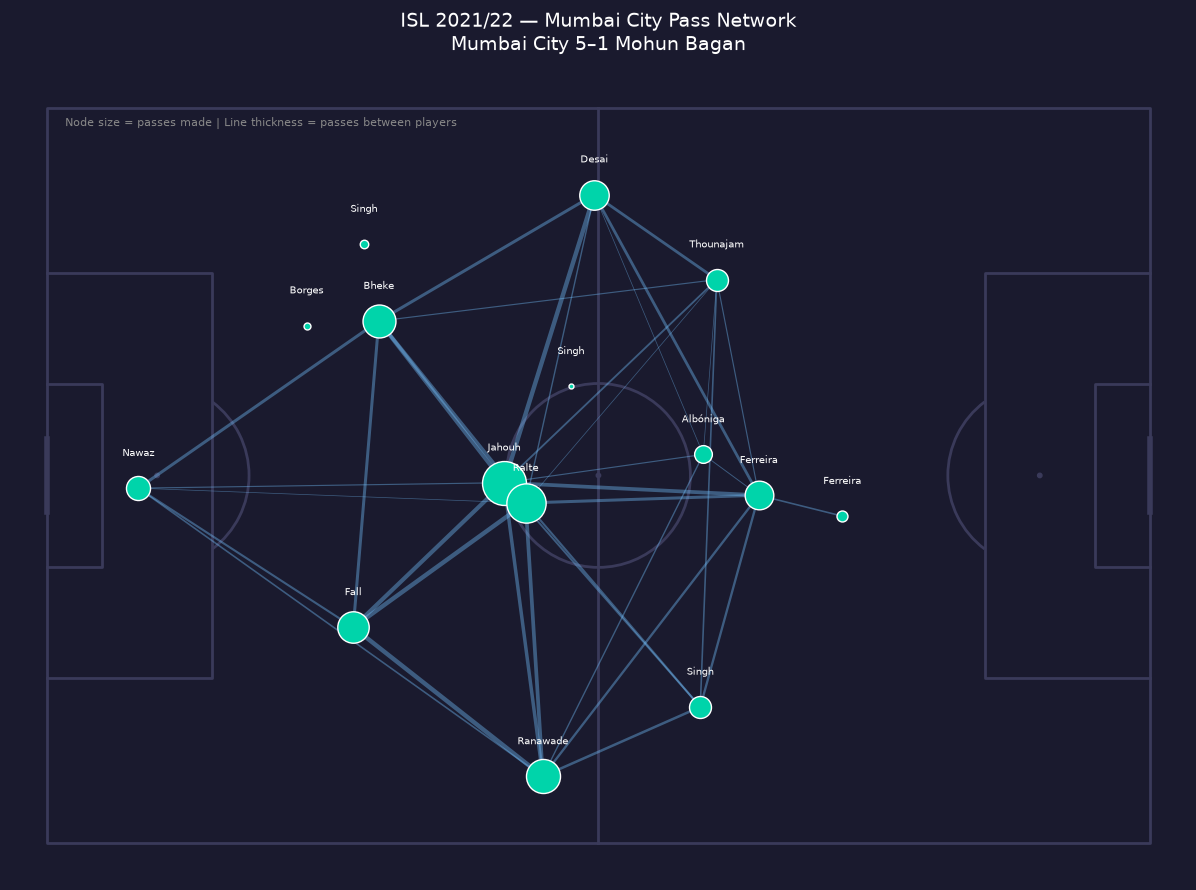

Saved!


In [8]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt
import numpy as np

# Get Mumbai City passes only
mumbai_passes = events[
    (events['type'] == 'Pass') & 
    (events['team'] == 'Mumbai City') &
    (events['pass_outcome'].isna())  # completed passes only
].copy()

# Extract locations
mumbai_passes['x'] = mumbai_passes['location'].apply(lambda loc: loc[0])
mumbai_passes['y'] = mumbai_passes['location'].apply(lambda loc: loc[1])
mumbai_passes['end_x'] = mumbai_passes['pass_end_location'].apply(lambda loc: loc[0])
mumbai_passes['end_y'] = mumbai_passes['pass_end_location'].apply(lambda loc: loc[1])

# Average position per player
avg_pos = mumbai_passes.groupby('player').agg(
    x=('x', 'mean'),
    y=('y', 'mean'),
    count=('x', 'count')
).reset_index()

# Count passes between pairs
mumbai_passes['pair'] = mumbai_passes.apply(
    lambda r: tuple(sorted([r['player'], r['pass_recipient']])), axis=1
)
pair_counts = mumbai_passes.groupby('pair').size().reset_index(name='passes')
pair_counts = pair_counts[pair_counts['passes'] >= 3]

# Draw pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='#1a1a2e', line_color='#3a3a5a')
fig, ax = pitch.draw(figsize=(14, 9))
fig.patch.set_facecolor('#1a1a2e')

# Draw lines between players
for _, row in pair_counts.iterrows():
    p1, p2 = row['pair']
    if p1 in avg_pos['player'].values and p2 in avg_pos['player'].values:
        x1 = avg_pos[avg_pos['player'] == p1]['x'].values[0]
        y1 = avg_pos[avg_pos['player'] == p1]['y'].values[0]
        x2 = avg_pos[avg_pos['player'] == p2]['x'].values[0]
        y2 = avg_pos[avg_pos['player'] == p2]['y'].values[0]
        lw = row['passes'] / pair_counts['passes'].max() * 6
        ax.plot([x1, x2], [y1, y2], color='#74c0fc', alpha=0.4, linewidth=lw, zorder=2)

# Draw player nodes
for _, row in avg_pos.iterrows():
    size = row['count'] / avg_pos['count'].max() * 1000
    pitch.scatter(row['x'], row['y'], s=size, color='#00d4aa',
                  edgecolors='white', linewidth=1, ax=ax, zorder=3)
    # Short name
    short = row['player'].split()[-1]
    ax.text(row['x'], row['y'] - 3.5, short, color='white',
            fontsize=7, ha='center', zorder=4)

ax.set_title('ISL 2021/22 — Mumbai City Pass Network\nMumbai City 5–1 Mohun Bagan',
             color='white', fontsize=14, pad=15)
ax.text(2, 2, 'Node size = passes made | Line thickness = passes between players',
        color='#888', fontsize=8)

plt.tight_layout()
plt.savefig('isl_mumbai_passnetwork.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

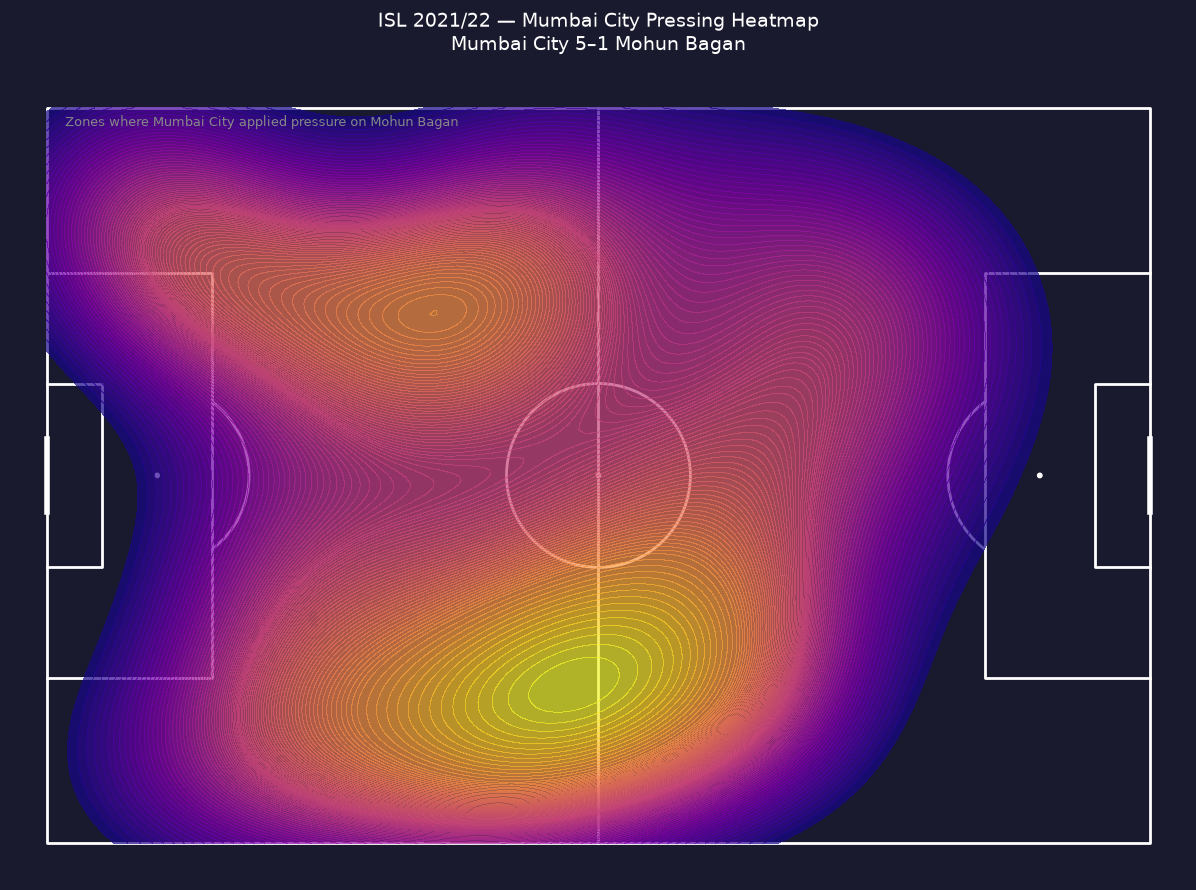

Saved!


In [9]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# Get Mumbai City pressures
pressures = events[
    (events['type'] == 'Pressure') &
    (events['team'] == 'Mumbai City')
].copy()

pressures['x'] = pressures['location'].apply(lambda loc: loc[0])
pressures['y'] = pressures['location'].apply(lambda loc: loc[1])

# Draw heatmap
pitch = Pitch(pitch_type='statsbomb', pitch_color='#1a1a2e', line_color='white')
fig, ax = pitch.draw(figsize=(14, 9))
fig.patch.set_facecolor('#1a1a2e')

pitch.kdeplot(pressures['x'], pressures['y'],
              ax=ax, cmap='plasma',
              fill=True, levels=100,
              alpha=0.7)

ax.set_title('ISL 2021/22 — Mumbai City Pressing Heatmap\nMumbai City 5–1 Mohun Bagan',
             color='white', fontsize=14, pad=15)
ax.text(2, 2, 'Zones where Mumbai City applied pressure on Mohun Bagan',
        color='#888', fontsize=9)

plt.tight_layout()
plt.savefig('isl_mumbai_pressing_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")